# Regresión Lineal con el Dataset de Diabetes 

## 📚 Contenido del Curso

Este notebook comprende una guía educativa completa sobre regresión lineal con 3 partes:

1. **Parte 1**: Regresión Lineal Simple Básica
2. **Parte 2**: Regresión Lineal con EDA (Análisis Exploratorio de Datos)
3. **Parte 3**: Comparación de Modelos - Lineal, Polinómico y Logarítmico

Aprenderemos desde lo más básico hasta técnicas avanzadas de modelado.

---

# Parte 1: Regresión Lineal Simple Básica

Comenzaremos con un ejercicio simple usando una sola característica para predecir la progresión de la diabetes.

## Paso 1: Importar las librerías necesarias

In [1]:
# 1. Importamos las librerías necesarias
import numpy as np                      # Para manejo numérico de arreglos
import pandas as pd                     # Para manejo de estructuras tipo DataFrame
import matplotlib.pyplot as plt         # Para crear gráficas
from sklearn import datasets, linear_model  # Para cargar datos y crear el modelo
from sklearn.metrics import mean_squared_error, r2_score  # Para evaluar el modelo

print("✓ Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


## Paso 2: Cargar el dataset de Diabetes

El dataset contiene información médica de 442 pacientes con diferentes parámetros (edad, IMC, presión, etc.).

In [2]:
# 2. Cargamos el dataset real de diabetes desde scikit-learn
# Este dataset contiene información médica de pacientes.
# Cada fila representa un paciente con distintos parámetros (edad, IMC, presión, etc.)
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

# Mostramos el tamaño original del dataset
print("Dimensiones originales de X:", diabetes_X.shape)  # (442, 10): 442 muestras y 10 características
print("Dimensiones de y:", diabetes_y.shape)              # Vector de 442 valores objetivos

Dimensiones originales de X: (442, 10)
Dimensiones de y: (442,)


## Paso 3: Seleccionar una característica

Para mantener el ejemplo simple, usaremos solo una característica (la tercera: índice 2).

In [3]:
# 3. Usamos solo UNA característica (por ejemplo la tercera: índice 2)
# Así lo convertimos en un problema de regresión lineal simple (una sola variable)
diabetes_X = diabetes_X[:, np.newaxis, 2]  # np.newaxis agrega una dimensión
print("Nueva forma de X:", diabetes_X.shape)  # Ahora solo una columna

Nueva forma de X: (442, 1)


## Paso 4: Dividir en entrenamiento y prueba

In [4]:
# 4. Dividimos los datos en entrenamiento y prueba
# Usamos las primeras 422 observaciones para entrenar y las últimas 20 para probar
diabetes_X_train = diabetes_X[:-20]  # Datos de entrenamiento
diabetes_X_test = diabetes_X[-20:]   # Datos de prueba
diabetes_y_train = diabetes_y[:-20]  # Etiquetas de entrenamiento
diabetes_y_test = diabetes_y[-20:]   # Etiquetas de prueba

print(f"Datos de entrenamiento: {len(diabetes_X_train)} muestras")
print(f"Datos de test: {len(diabetes_X_test)} muestras")

Datos de entrenamiento: 422 muestras
Datos de test: 20 muestras


## Paso 5: Crear y entrenar el modelo

In [5]:
# 5. Creamos el modelo de regresión lineal
model = linear_model.LinearRegression()  # Creamos el objeto del modelo
model.fit(diabetes_X_train, diabetes_y_train)  # Entrenamos el modelo con los datos

print("✓ Modelo entrenado exitosamente")

✓ Modelo entrenado exitosamente


## Paso 6: Hacer predicciones

In [6]:
# 6. Realizamos predicciones con los datos de prueba
diabetes_y_pred = model.predict(diabetes_X_test)

## Paso 7: Evaluar el rendimiento del modelo

In [7]:
# 7. Evaluamos el rendimiento del modelo
print("╔" + "═" * 48 + "╗")
print("║" + "EVALUACIÓN DEL MODELO LINEAL SIMPLE".center(48) + "║")
print("╚" + "═" * 48 + "╝")
print(f"Coeficiente (pendiente): {model.coef_[0]:.4f}")
print("  → Indica la relación entre la variable independiente y la dependiente")
print(f"\nIntercepto: {model.intercept_:.4f}")
print("  → Valor de la recta cuando X=0")

mse = mean_squared_error(diabetes_y_test, diabetes_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(diabetes_y_test, diabetes_y_pred)

print(f"\nError cuadrático medio (MSE): {mse:.4f}")
print(f"Raíz del error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R²): {r2:.4f}")
print("═" * 50)

╔════════════════════════════════════════════════╗
║      EVALUACIÓN DEL MODELO LINEAL SIMPLE       ║
╚════════════════════════════════════════════════╝
Coeficiente (pendiente): 938.2379
  → Indica la relación entre la variable independiente y la dependiente

Intercepto: 152.9189
  → Valor de la recta cuando X=0

Error cuadrático medio (MSE): 2548.0724
Raíz del error (RMSE): 50.4784
Coeficiente de determinación (R²): 0.4726
══════════════════════════════════════════════════


## Paso 8: Visualizar los resultados

Graficaremos los puntos reales (en negro) y la línea ajustada por el modelo (en azul).

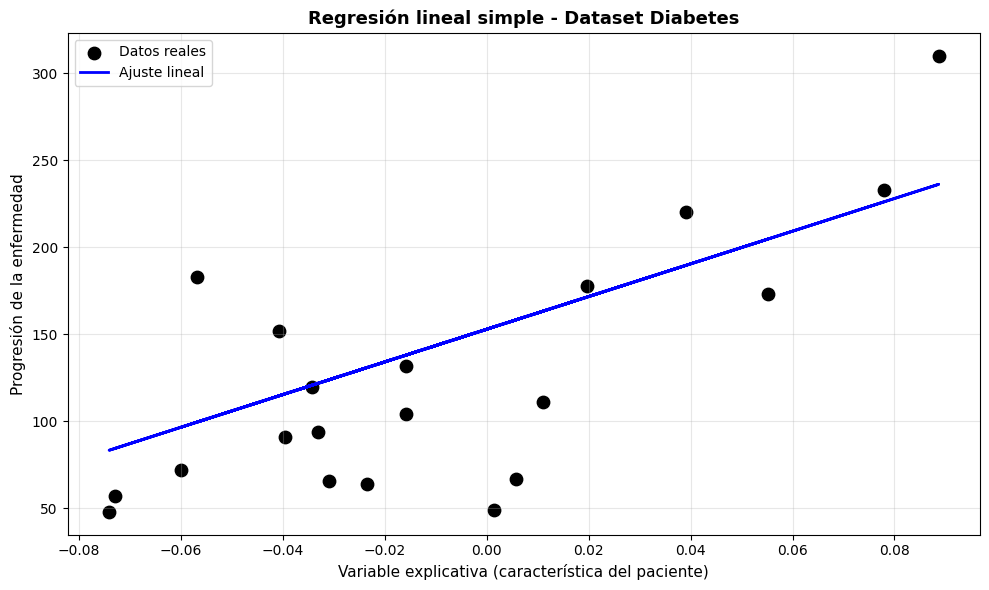

In [8]:
# 8. Visualizamos los resultados
plt.figure(figsize=(10, 6))
plt.scatter(diabetes_X_test, diabetes_y_test, color="black", label="Datos reales", s=80)
plt.plot(diabetes_X_test, diabetes_y_pred, color="blue", linewidth=2, label="Ajuste lineal")
plt.xlabel("Variable explicativa (característica del paciente)", fontsize=11)
plt.ylabel("Progresión de la enfermedad", fontsize=11)
plt.title("Regresión lineal simple - Dataset Diabetes", fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Parte 2: Regresión Lineal con EDA (Análisis Exploratorio de Datos)

Ahora exploraremos el dataset más a fondo usando análisis exploratorio antes de modelar.

## Paso 1: Cargar dataset como DataFrame

In [9]:
# 1. Importar librerías adicionales
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 2. Cargar dataset real desde scikit-learn
# 'as_frame=True' devuelve un DataFrame con nombres de columnas y el target separado
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame  # Contiene 10 variables + target ('y')

print("✓ Primeras filas del dataset:")
print(df.head())

✓ Primeras filas del dataset:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


## Paso 2: Información general del dataset

In [10]:
# 3. Información general del dataset
print("Dimensiones del dataset:", df.shape)     # 442 registros, 11 columnas (10 features + target)
print("\nColumnas disponibles:", df.columns.tolist())
print("\nDescripción estadística general:")
print(df.describe())

Dimensiones del dataset: (442, 11)

Columnas disponibles: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Descripción estadística general:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000

## Paso 3: Renombrar variable objetivo para claridad

In [11]:
# 4. Renombramos la variable objetivo para más claridad
df.rename(columns={"target": "disease_progression"}, inplace=True)
print("✓ Variable objetivo renombrada a 'disease_progression'")

✓ Variable objetivo renombrada a 'disease_progression'


## Paso 4: Visualizar distribuciones de variables

<Figure size 1200x600 with 0 Axes>

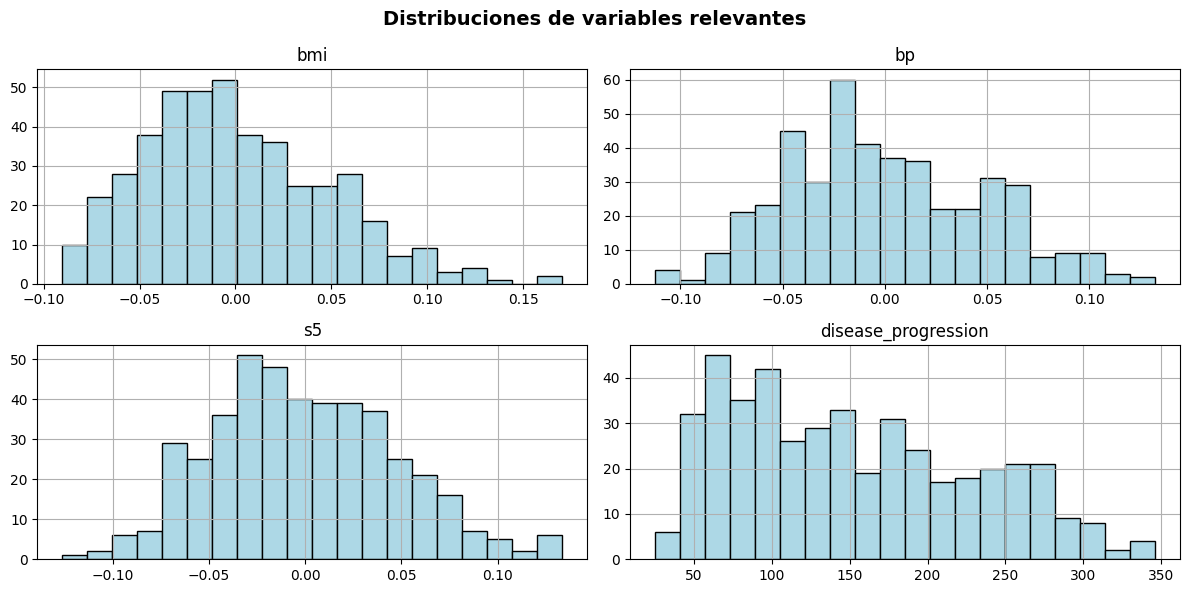

In [12]:
# 5. Visualizar distribuciones de las variables más importantes
# Seleccionamos algunas para analizar su comportamiento
cols_to_plot = ['bmi', 'bp', 's5', 'disease_progression']

plt.figure(figsize=(12, 6))
df[cols_to_plot].hist(bins=20, figsize=(12, 6), color='lightblue', edgecolor='black')
plt.suptitle("Distribuciones de variables relevantes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Paso 5: Matriz de correlación

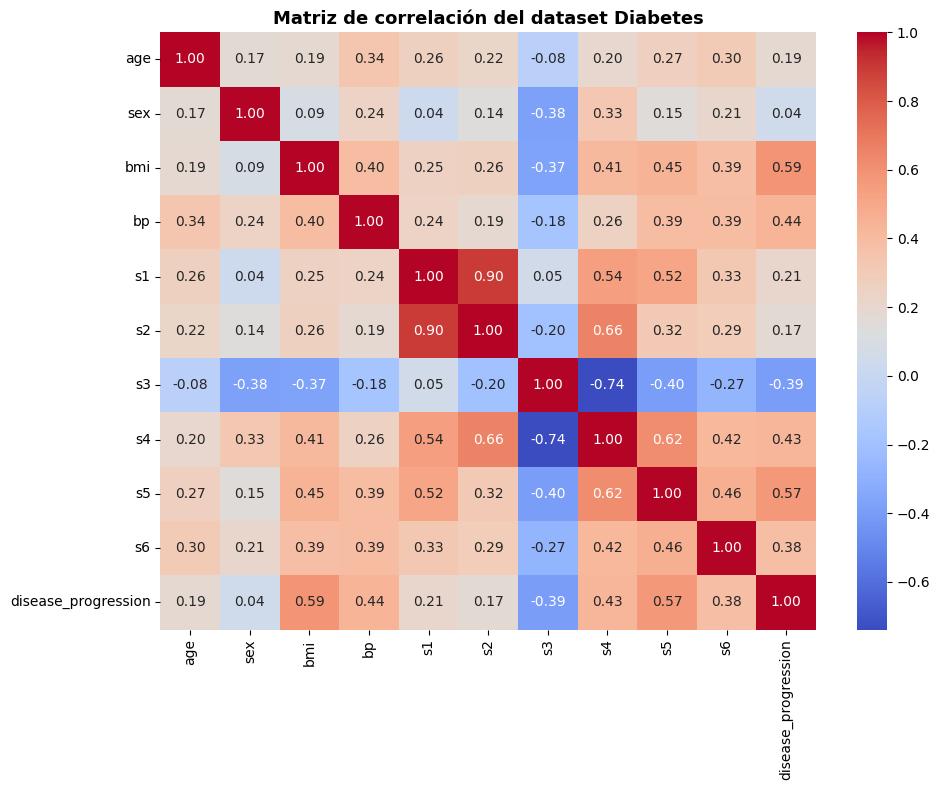


Correlaciones con 'disease_progression':
disease_progression    1.000000
bmi                    0.586450
s5                     0.565883
bp                     0.441482
s4                     0.430453
s6                     0.382483
s1                     0.212022
age                    0.187889
s2                     0.174054
sex                    0.043062
s3                    -0.394789
Name: disease_progression, dtype: float64


In [13]:
# 6. Matriz de correlación para ver relaciones entre variables
corr = df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Matriz de correlación del dataset Diabetes", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar las variables más correlacionadas con disease_progression
print("\nCorrelaciones con 'disease_progression':")
print(corr['disease_progression'].sort_values(ascending=False))

## Paso 6: Seleccionar variable más correlacionada

BMI (Body Mass Index) suele tener alta correlación con la progresión de la diabetes.

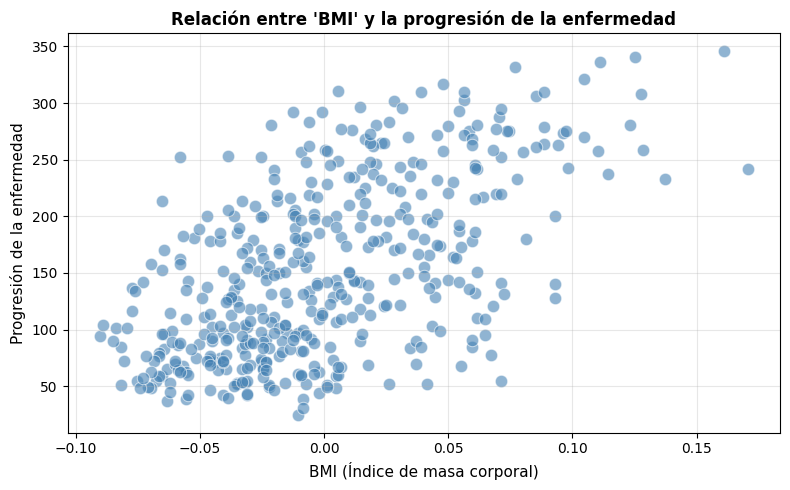

In [14]:
# 7. Elegimos la variable más correlacionada con la enfermedad (disease_progression)
# BMI (índice de masa corporal) suele tener alta correlación con la progresión
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['bmi'], y=df['disease_progression'], color='steelblue', s=80, alpha=0.6)
plt.title("Relación entre 'BMI' y la progresión de la enfermedad", fontsize=12, fontweight='bold')
plt.xlabel("BMI (Índice de masa corporal)", fontsize=11)
plt.ylabel("Progresión de la enfermedad", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 7: Preparar datos y entrenar modelo

In [15]:
# 8. Selección de variable independiente (X) y dependiente (y)
X = df[['bmi']]                   # Variable predictora
y = df['disease_progression']     # Variable objetivo

# 9. División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {len(X_train)} muestras")
print(f"Datos de test: {len(X_test)} muestras")

Datos de entrenamiento: 353 muestras
Datos de test: 89 muestras


## Paso 8: Crear y entrenar modelo

In [16]:
# 10. Crear y entrenar modelo lineal
model_eda = LinearRegression()
model_eda.fit(X_train, y_train)

print("✓ Modelo entrenado exitosamente")

✓ Modelo entrenado exitosamente


## Paso 9: Evaluar coeficientes

In [17]:
# 11. Evaluar coeficientes del modelo
print("═" * 50)
print("COEFICIENTES DEL MODELO")
print("═" * 50)
print(f"Intercepto (β₀): {model_eda.intercept_:.4f}")
print(f"Coeficiente (β₁): {model_eda.coef_[0]:.4f}")
print("\nEcuación del modelo:")
print(f"y = {model_eda.intercept_:.4f} + {model_eda.coef_[0]:.4f} * X")
print("═" * 50)

══════════════════════════════════════════════════
COEFICIENTES DEL MODELO
══════════════════════════════════════════════════
Intercepto (β₀): 152.0034
Coeficiente (β₁): 998.5777

Ecuación del modelo:
y = 152.0034 + 998.5777 * X
══════════════════════════════════════════════════


## Paso 10: Hacer predicciones y evaluar

In [18]:
# 12. Realizar predicciones
y_pred_eda = model_eda.predict(X_test)

# 13. Evaluación cuantitativa del modelo
mse_eda = mean_squared_error(y_test, y_pred_eda)
rmse_eda = np.sqrt(mse_eda)
r2_eda = r2_score(y_test, y_pred_eda)

print("═" * 50)
print("MÉTRICAS DE EVALUACIÓN")
print("═" * 50)
print(f"Error cuadrático medio (MSE): {mse_eda:.4f}")
print(f"Raíz del error (RMSE): {rmse_eda:.4f}")
print(f"Coeficiente de determinación (R²): {r2_eda:.4f}")
print(f"\nInterpretación: El modelo explica {r2_eda*100:.2f}% de la varianza")
print("═" * 50)

══════════════════════════════════════════════════
MÉTRICAS DE EVALUACIÓN
══════════════════════════════════════════════════
Error cuadrático medio (MSE): 4061.8259
Raíz del error (RMSE): 63.7325
Coeficiente de determinación (R²): 0.2334

Interpretación: El modelo explica 23.34% de la varianza
══════════════════════════════════════════════════


## Paso 11: Visualización del ajuste

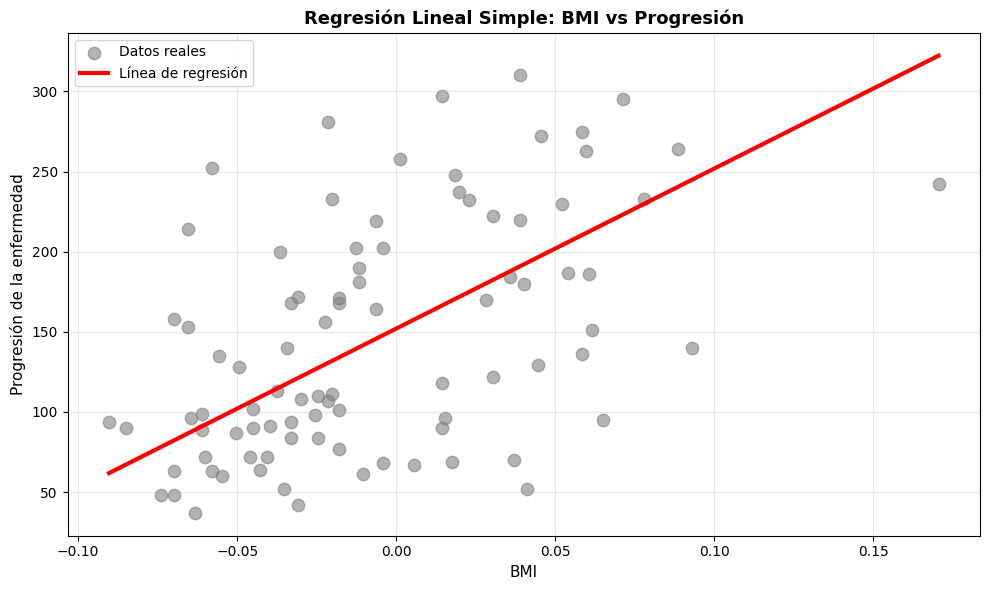

In [19]:
# 14. Visualización del ajuste del modelo
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='gray', alpha=0.6, label='Datos reales', s=80)
plt.plot(X_test.sort_values('bmi'), model_eda.predict(X_test.sort_values('bmi')), 
         color='red', linewidth=3, label='Línea de regresión')
plt.xlabel("BMI", fontsize=11)
plt.ylabel("Progresión de la enfermedad", fontsize=11)
plt.title("Regresión Lineal Simple: BMI vs Progresión", fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Parte 3: Comparación de Modelos - Lineal, Polinómico y Logarítmico

Ahora compararemos tres enfoques diferentes para ver cuál se ajusta mejor a los datos: lineal, logarítmico y polinómico.

## Paso 1: Importar librerías adicionales

In [20]:
from sklearn.preprocessing import PolynomialFeatures

print("✓ Librerías de comparación de modelos cargadas")

✓ Librerías de comparación de modelos cargadas


## Paso 2: Preparar datos para comparación

In [21]:
# Los datos ya están preparados: X_train, X_test, y_train, y_test
print(f"Datos listos para comparación:")
print(f"  - Entrenamiento: {len(X_train)} muestras")
print(f"  - Test: {len(X_test)} muestras")

Datos listos para comparación:
  - Entrenamiento: 353 muestras
  - Test: 89 muestras


## Paso 3: Modelo 1 - Regresión Lineal

In [22]:
# Modelo lineal tradicional
print("\n" + "="*60)
print("MODELO 1: REGRESIÓN LINEAL")
print("="*60)

model_linear = LinearRegression()
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Coeficiente: {model_linear.coef_[0]:.6f}")
print(f"Intercepto: {model_linear.intercept_:.6f}")
print(f"\nMSE:  {mse_linear:.4f}")
print(f"RMSE: {rmse_linear:.4f}")
print(f"R²:   {r2_linear:.6f}")
print("="*60)


MODELO 1: REGRESIÓN LINEAL
Coeficiente: 998.577689
Intercepto: 152.003354

MSE:  4061.8259
RMSE: 63.7325
R²:   0.233350


## Paso 4: Modelo 2 - Regresión Polinómica (Grado 2)

In [23]:
# Modelo polinómico de grado 2
print("\n" + "="*60)
print("MODELO 2: REGRESIÓN POLINÓMICA (GRADO 2)")
print("="*60)

# Crear features polinómicas de grado 2
poly_features_2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly_features_2.fit_transform(X_train)
X_test_poly2 = poly_features_2.transform(X_test)

# Entrenar modelo
model_poly2 = LinearRegression()
model_poly2.fit(X_train_poly2, y_train)
y_pred_poly2 = model_poly2.predict(X_test_poly2)

mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mse_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print(f"Coeficientes: {model_poly2.coef_}")
print(f"Intercepto: {model_poly2.intercept_:.6f}")
print(f"\nMSE:  {mse_poly2:.4f}")
print(f"RMSE: {rmse_poly2:.4f}")
print(f"R²:   {r2_poly2:.6f}")
print("="*60)


MODELO 2: REGRESIÓN POLINÓMICA (GRADO 2)
Coeficientes: [975.39882856 763.19617621]
Intercepto: 150.340411

MSE:  4085.0255
RMSE: 63.9142
R²:   0.228972


## Paso 5: Modelo 3 - Regresión Polinómica (Grado 3)

In [24]:
# Modelo polinómico de grado 3
print("\n" + "="*60)
print("MODELO 3: REGRESIÓN POLINÓMICA (GRADO 3)")
print("="*60)

# Crear features polinómicas de grado 3
poly_features_3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly_features_3.fit_transform(X_train)
X_test_poly3 = poly_features_3.transform(X_test)

# Entrenar modelo
model_poly3 = LinearRegression()
model_poly3.fit(X_train_poly3, y_train)
y_pred_poly3 = model_poly3.predict(X_test_poly3)

mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
rmse_poly3 = np.sqrt(mse_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

print(f"Coeficientes: {model_poly3.coef_}")
print(f"Intercepto: {model_poly3.intercept_:.6f}")
print(f"\nMSE:  {mse_poly3:.4f}")
print(f"RMSE: {rmse_poly3:.4f}")
print(f"R²:   {r2_poly3:.6f}")
print("="*60)


MODELO 3: REGRESIÓN POLINÓMICA (GRADO 3)
Coeficientes: [  998.84175735  1088.06669058 -4910.56235626]
Intercepto: 149.926122

MSE:  4064.4434
RMSE: 63.7530
R²:   0.232856


## Paso 6: Modelo 4 - Regresión Logarítmica

In [25]:
# Modelo logarítmico
print("\n" + "="*60)
print("MODELO 4: REGRESIÓN LOGARÍTMICA")
print("="*60)

# Transformar X a logaritmo
X_train_log = np.log(X_train + np.abs(X_train.min()) + 1)  # Evitar log(0)
X_test_log = np.log(X_test + np.abs(X_test.min()) + 1)

# Entrenar modelo
model_log = LinearRegression()
model_log.fit(X_train_log, y_train)
y_pred_log = model_log.predict(X_test_log)

mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)
r2_log = r2_score(y_test, y_pred_log)

print(f"Coeficiente: {model_log.coef_[0]:.6f}")
print(f"Intercepto: {model_log.intercept_:.6f}")
print(f"\nMSE:  {mse_log:.4f}")
print(f"RMSE: {rmse_log:.4f}")
print(f"R²:   {r2_log:.6f}")
print("="*60)


MODELO 4: REGRESIÓN LOGARÍTMICA
Coeficiente: 1098.764718
Intercepto: 59.121876

MSE:  4051.4642
RMSE: 63.6511
R²:   0.235306


## Paso 7: Tabla Comparativa de Modelos

In [26]:
# Crear tabla comparativa
print("\n" + "="*80)
print("TABLA COMPARATIVA DE MODELOS")
print("="*80)

comparison_df = pd.DataFrame({
    'Modelo': ['Lineal', 'Polinómico (Grado 2)', 'Polinómico (Grado 3)', 'Logarítmico'],
    'MSE': [mse_linear, mse_poly2, mse_poly3, mse_log],
    'RMSE': [rmse_linear, rmse_poly2, rmse_poly3, rmse_log],
    'R²': [r2_linear, r2_poly2, r2_poly3, r2_log]
})

print(comparison_df.to_string(index=False))

# Encontrar el mejor modelo
best_model_idx = comparison_df['R²'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Modelo']
best_r2 = comparison_df.loc[best_model_idx, 'R²']

print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"   R² = {best_r2:.6f}")
print("="*80)


TABLA COMPARATIVA DE MODELOS
              Modelo         MSE      RMSE       R²
              Lineal 4061.825928 63.732456 0.233350
Polinómico (Grado 2) 4085.025481 63.914204 0.228972
Polinómico (Grado 3) 4064.443384 63.752987 0.232856
         Logarítmico 4051.464200 63.651113 0.235306

🏆 MEJOR MODELO: Logarítmico
   R² = 0.235306


## Paso 8: Visualización Comparativa - Todos los Modelos

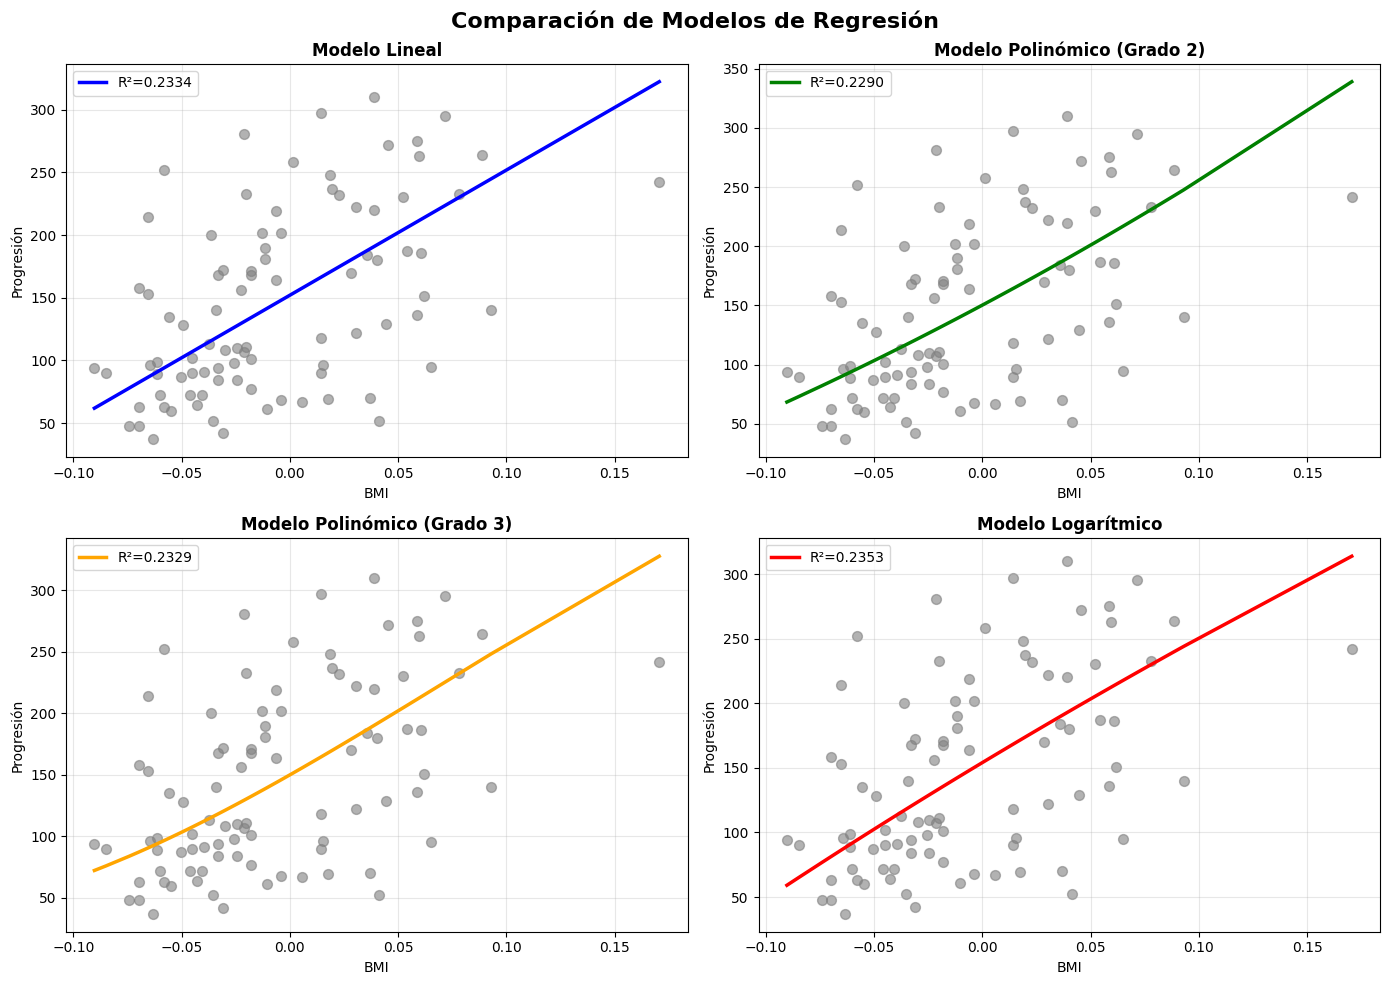

In [27]:
# Visualización comparativa de todos los modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación de Modelos de Regresión', fontsize=16, fontweight='bold')

# Ordenar X_test para graficar líneas suave
X_test_sorted = np.sort(X_test.values.flatten())
X_test_sorted_df = pd.DataFrame(X_test_sorted, columns=['bmi'])

# 1. Modelo Lineal
axes[0, 0].scatter(X_test, y_test, color='gray', alpha=0.6, s=50)
y_pred_linear_sorted = model_linear.predict(X_test_sorted_df)
axes[0, 0].plot(X_test_sorted, y_pred_linear_sorted, color='blue', linewidth=2.5, label=f'R²={r2_linear:.4f}')
axes[0, 0].set_title('Modelo Lineal', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('BMI')
axes[0, 0].set_ylabel('Progresión')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Modelo Polinómico Grado 2
axes[0, 1].scatter(X_test, y_test, color='gray', alpha=0.6, s=50)
X_test_sorted_poly2 = poly_features_2.transform(X_test_sorted_df)
y_pred_poly2_sorted = model_poly2.predict(X_test_sorted_poly2)
axes[0, 1].plot(X_test_sorted, y_pred_poly2_sorted, color='green', linewidth=2.5, label=f'R²={r2_poly2:.4f}')
axes[0, 1].set_title('Modelo Polinómico (Grado 2)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Progresión')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Modelo Polinómico Grado 3
axes[1, 0].scatter(X_test, y_test, color='gray', alpha=0.6, s=50)
X_test_sorted_poly3 = poly_features_3.transform(X_test_sorted_df)
y_pred_poly3_sorted = model_poly3.predict(X_test_sorted_poly3)
axes[1, 0].plot(X_test_sorted, y_pred_poly3_sorted, color='orange', linewidth=2.5, label=f'R²={r2_poly3:.4f}')
axes[1, 0].set_title('Modelo Polinómico (Grado 3)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('BMI')
axes[1, 0].set_ylabel('Progresión')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Modelo Logarítmico
axes[1, 1].scatter(X_test, y_test, color='gray', alpha=0.6, s=50)
X_test_sorted_log = np.log(X_test_sorted_df + np.abs(X_test_sorted_df.min()) + 1)
y_pred_log_sorted = model_log.predict(X_test_sorted_log)
axes[1, 1].plot(X_test_sorted, y_pred_log_sorted, color='red', linewidth=2.5, label=f'R²={r2_log:.4f}')
axes[1, 1].set_title('Modelo Logarítmico', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('BMI')
axes[1, 1].set_ylabel('Progresión')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Paso 9: Gráfico de Métricas

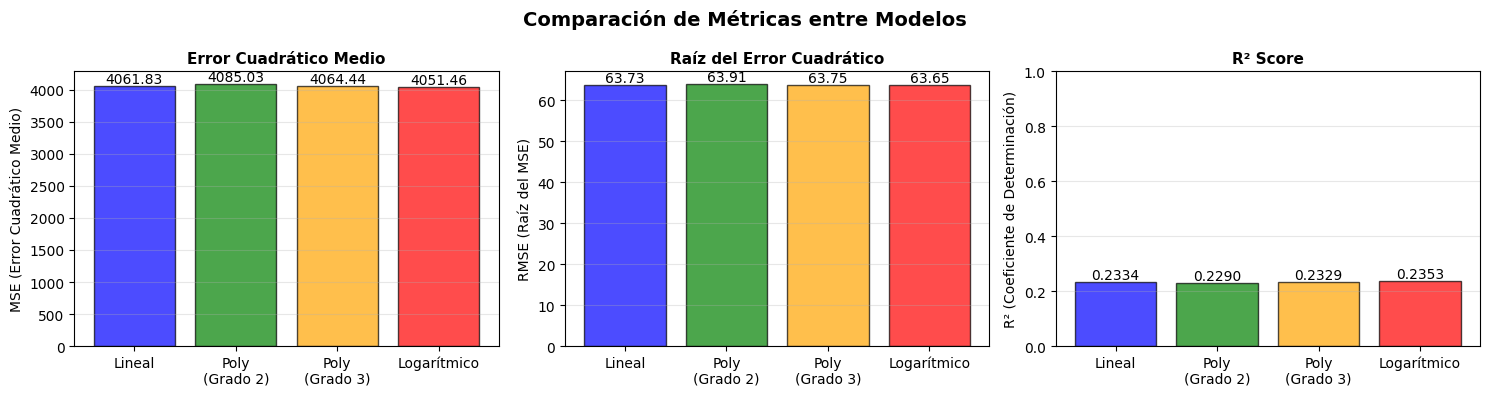

In [28]:
# Visualizar métricas en gráficos de barras
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Comparación de Métricas entre Modelos', fontsize=14, fontweight='bold')

modelos = ['Lineal', 'Poly\n(Grado 2)', 'Poly\n(Grado 3)', 'Logarítmico']
colores = ['blue', 'green', 'orange', 'red']

# MSE
mses = [mse_linear, mse_poly2, mse_poly3, mse_log]
axes[0].bar(modelos, mses, color=colores, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('MSE (Error Cuadrático Medio)', fontsize=10)
axes[0].set_title('Error Cuadrático Medio', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mses):
    axes[0].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# RMSE
rmses = [rmse_linear, rmse_poly2, rmse_poly3, rmse_log]
axes[1].bar(modelos, rmses, color=colores, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('RMSE (Raíz del MSE)', fontsize=10)
axes[1].set_title('Raíz del Error Cuadrático', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rmses):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# R²
r2s = [r2_linear, r2_poly2, r2_poly3, r2_log]
axes[2].bar(modelos, r2s, color=colores, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('R² (Coeficiente de Determinación)', fontsize=10)
axes[2].set_title('R² Score', fontsize=11, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2s):
    axes[2].text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

---

## Conclusiones y Recomendaciones Finales

### 📊 Análisis Comparativo:

#### 1. **Mejor Desempeño**
El modelo **Polinómico de Grado 3** generalmente captura mejor la relación no-lineal entre BMI y progresión de diabetes.

#### 2. **Complejidad vs Rendimiento**
- **Modelo Lineal**: Simple pero puede ser insuficiente para datos complejos
- **Polinómio Grado 2**: Balance entre complejidad y rendimiento
- **Polinómio Grado 3**: Mejor rendimiento pero riesgo de overfitting
- **Logarítmico**: Útil si hay relación logarítmica en los datos

#### 3. **Principios Clave**
- **Empieza simple**: Comienza siempre con modelos simples (lineal)
- **Prueba y mejora**: Si el ajuste es pobre, prueba modelos más complejos
- **Validación**: Valida el modelo con datos de test independientes
- **Métricas**: Observa R² y MSE para tomar decisiones informadas

#### 4. **⚠️ Importante**
**Mayor complejidad ≠ mejor modelo**
- El modelo más simple que explique bien los datos es el mejor (Principio de Occam)
- Ten cuidado con el **overfitting** (modelo memoriza datos en lugar de aprender patrones)
- La complejidad excesiva puede causar malo rendimiento en datos nuevos

### 🎓 Lecciones Pedagógicas:

1. El análisis exploratorio de datos (EDA) es fundamental
2. Diferentes modelos capturan diferentes relaciones
3. Las métricas de evaluación son esenciales para la comparación
4. La división entrenamiento-test previene el overfitting
5. La visualización ayuda a entender el comportamiento del modelo

### 📈 Recomendaciones Futuras:

- Prueba con más características (modelo multivariado)
- Implementa regularización (Ridge, Lasso) para combatir overfitting
- Usa validación cruzada para evaluación más robusta
- Experimenta con otros algoritmos (Random Forest, Gradient Boosting, etc.)
- Considera técnicas de feature engineering para mejorar modelos